In [1]:
import json, os, time
import numpy as np
import torch
import torch.nn as nn
import pennylane as qml
import matplotlib.pyplot as plt

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cpu")   # PennyLane default.qubit simulates on CPU
print("torch", torch.__version__, "| pennylane", qml.__version__, "| device:", DEVICE)

# --- Experiment configuration (env-overridable so the sweep stays tractable) ---
QUBIT_LIST  = [int(v) for v in os.environ.get("QAPINN_QUBITS", "3,5,8").split(",")]
LAYER_LIST  = [int(v) for v in os.environ.get("QAPINN_LAYERS", "2,4,6").split(",")]
SWEEP_EPOCHS = int(os.environ.get("QAPINN_EPOCHS", 120))   # Adam iters per config
N_DATA_Q  = int(os.environ.get("QAPINN_NDATA", 128))       # supervised anchors
N_COLL_Q  = int(os.environ.get("QAPINN_NCOLL", 96))        # PDE collocation points
N_BCIC_Q  = int(os.environ.get("QAPINN_NBCIC", 64))        # IC / BC points
LR        = float(os.environ.get("QAPINN_LR", 1e-2))
print(f"sweep qubits={QUBIT_LIST}  layers={LAYER_LIST}  epochs={SWEEP_EPOCHS}")
print(f"points  data={N_DATA_Q} coll={N_COLL_Q} bc/ic={N_BCIC_Q}  lr={LR}")

torch 2.12.1+cu130 | pennylane 0.45.1 | device: cpu
sweep qubits=[3, 5, 8]  layers=[2, 4, 6]  epochs=120
points  data=128 coll=96 bc/ic=64  lr=0.01


## 1. Load the FEniCSx configuration and dataset

Exactly as in the classical baseline: `nu`, the domain and the time horizon come
from `output/config.json`, guaranteeing the PDE residual is consistent with the
FEM ground truth. We keep the point counts small here because every collocation
point is pushed through a quantum-circuit simulation.

In [2]:
OUTPUT_DIR = "output"
with open(os.path.join(OUTPUT_DIR, "config.json")) as fh:
    fem_cfg = json.load(fh)

NU   = float(fem_cfg["nu"])
XMIN = float(fem_cfg["xmin"]); XMAX = float(fem_cfg["xmax"])
TMIN = 0.0;                    TMAX = float(fem_cfg["T"])
print(f"nu={NU}  x in [{XMIN},{XMAX}]  t in [{TMIN},{TMAX}]  IC={fem_cfg['initial_condition']}")

# [x, t, u] contract produced by src.io.pinn_dataset
data = np.load(os.path.join(OUTPUT_DIR, "numpy", "burgers_dataset.npy"))
assert data.ndim == 2 and data.shape[1] == 3, f"unexpected dataset shape {data.shape}"
x_all = data[:, 0:1]; t_all = data[:, 1:2]; u_all = data[:, 2:3]
print("dataset:", data.shape, "| u range [%.3f, %.3f]" % (u_all.min(), u_all.max()))

# Full FEM grid (for evaluation / plots): x (nx,), t (nt,), u (nt, nx)
grid = np.load(os.path.join(OUTPUT_DIR, "numpy", f"{fem_cfg['experiment_name']}.npz"))
x_grid, t_grid, U_grid = grid["x"], grid["t"], grid["u"]
print("FEM grid:", U_grid.shape)

nu=0.01  x in [0.0,1.0]  t in [0.0,1.0]  IC=sin
dataset: (150801, 3) | u range [-1.000, 1.000]
FEM grid: (501, 301)


## 2. Normalization and batch construction

Inputs are normalized to $[-1,1]$; the chain-rule factors `SX`, `ST` convert the
network's derivatives back to physical coordinates for the residual. `make_batches`
draws the supervised anchors, the interior collocation points (with
`requires_grad` so autograd can form the residual), and the IC/BC points.

In [3]:
def norm_x(x): return 2.0 * (x - XMIN) / (XMAX - XMIN) - 1.0
def norm_t(t): return 2.0 * (t - TMIN) / (TMAX - TMIN) - 1.0
SX = 2.0 / (XMAX - XMIN)   # d/dx  = SX * d/dx_hat
ST = 2.0 / (TMAX - TMIN)   # d/dt  = ST * d/dt_hat

def to_t(a): return torch.tensor(a, dtype=torch.float32, device=DEVICE)

X_LO_N = float(norm_x(np.array([[XMIN]]))[0, 0])
X_HI_N = float(norm_x(np.array([[XMAX]]))[0, 0])
T_LO_N = float(norm_t(np.array([[TMIN]]))[0, 0])

def make_batches(n_data=N_DATA_Q, n_coll=N_COLL_Q, n_bcic=N_BCIC_Q):
    # supervised anchors sampled from the FEM dataset
    sub = np.random.choice(len(data), size=min(n_data, len(data)), replace=False)
    xd = to_t(norm_x(x_all[sub])); td = to_t(norm_t(t_all[sub])); ud = to_t(u_all[sub])
    # interior collocation points for the PDE residual (normalized cube)
    xc = (torch.rand(n_coll, 1, device=DEVICE) * 2 - 1).requires_grad_(True)
    tc = (torch.rand(n_coll, 1, device=DEVICE) * 2 - 1).requires_grad_(True)
    # initial condition u(x,0) = sin(2 pi x)
    xi = torch.rand(n_bcic, 1, device=DEVICE) * 2 - 1
    x_phys_ic = (xi + 1) / 2 * (XMAX - XMIN) + XMIN
    u_ic = torch.sin(2 * np.pi * x_phys_ic)
    t_ic = torch.full_like(xi, T_LO_N)
    # Dirichlet boundaries u(0,t) = u(1,t) = 0
    tb = torch.rand(n_bcic, 1, device=DEVICE) * 2 - 1
    xb_lo = torch.full_like(tb, X_LO_N)
    xb_hi = torch.full_like(tb, X_HI_N)
    return dict(xd=xd, td=td, ud=ud, xc=xc, tc=tc,
                xi=xi, u_ic=u_ic, t_ic=t_ic, tb=tb, xb_lo=xb_lo, xb_hi=xb_hi)

def resample_collocation(b, n_coll=N_COLL_Q):
    b["xc"] = (torch.rand(n_coll, 1, device=DEVICE) * 2 - 1).requires_grad_(True)
    b["tc"] = (torch.rand(n_coll, 1, device=DEVICE) * 2 - 1).requires_grad_(True)

print("batch helper ready | normalized bounds x:[%.1f,%.1f] t0:%.1f" % (X_LO_N, X_HI_N, T_LO_N))

batch helper ready | normalized bounds x:[-1.0,1.0] t0:-1.0


## 3. The hybrid quantum-classical network

**Data encoding.** `Linear(2 → n_qubits)` followed by a `tanh` scaled to
$[-\pi,\pi]$ maps $(\hat x, \hat t)$ onto the qubit rotation angles — a trainable
embedding into the quantum feature space.

**Quantum hidden layer** (`make_qnode`). Angle-encode each input on its wire with
`RY`, then apply $N$ variational layers. Every layer is a full single-qubit
`RX·RY·RZ` rotation block on each wire followed by a **ring of `CNOT`s**
(`i → (i+1) mod n`) providing full entanglement across the register.

**Measurement.** The circuit returns `qml.probs()` — the $2^{n_{qubits}}$-dim
probability state vector (a normalized, non-negative feature vector).

**Classical decoder.** A `tanh` MLP maps that probability vector to $u(x,t)$.

The QNode uses `interface="torch"` + `diff_method="backprop"` so PyTorch autograd
differentiates through the simulated circuit — including the **second-order**
derivative $u_{xx}$ the PDE residual requires — and updates the quantum rotation
parameters together with the classical weights.

In [4]:
def make_qnode(n_qubits, n_layers):
    dev = qml.device("default.qubit", wires=n_qubits)

    @qml.qnode(dev, interface="torch", diff_method="backprop")
    def circuit(inputs, weights):
        # --- data encoding: angle-embed (x,t)->angles onto each wire ---
        for i in range(n_qubits):
            qml.RY(inputs[..., i], wires=i)
        # --- N variational layers: rotations + ring entanglement ---
        for l in range(n_layers):
            for i in range(n_qubits):
                qml.RX(weights[l, i, 0], wires=i)
                qml.RY(weights[l, i, 1], wires=i)
                qml.RZ(weights[l, i, 2], wires=i)
            for i in range(n_qubits):                      # CNOT entangler ring
                qml.CNOT(wires=[i, (i + 1) % n_qubits])
        # --- measurement: full probability state vector (dim 2**n_qubits) ---
        return qml.probs(wires=range(n_qubits))

    return circuit


class QAPINN(nn.Module):
    def __init__(self, n_qubits, n_layers, hidden=32):
        super().__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        # classical encoder: (x,t) -> quantum embedding angles
        self.encoder = nn.Linear(2, n_qubits)
        # quantum hidden layer wrapped as a differentiable torch layer
        qnode = make_qnode(n_qubits, n_layers)
        self.qlayer = qml.qnn.TorchLayer(qnode, {"weights": (n_layers, n_qubits, 3)})
        # classical decoder: probability vector (2**n) -> scalar field u
        self.decoder = nn.Sequential(
            nn.Linear(2 ** n_qubits, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, 1),
        )
        for m in self.decoder:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)
        nn.init.xavier_normal_(self.encoder.weight); nn.init.zeros_(self.encoder.bias)

    def forward(self, x, t):
        angles = np.pi * torch.tanh(self.encoder(torch.cat([x, t], dim=1)))
        probs = self.qlayer(angles)                        # (B, 2**n_qubits)
        return self.decoder(probs)

# sanity: instantiate the smallest config and count parameters
_m = QAPINN(3, 2)
print(_m)
print("params (3 qubits, 2 layers):", sum(p.numel() for p in _m.parameters()))

QAPINN(
  (encoder): Linear(in_features=2, out_features=3, bias=True)
  (qlayer): <Quantum Torch Layer: func=circuit>
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)
params (3 qubits, 2 layers): 1404


## 4. PDE residual and the composite physics-informed loss

The residual is formed with `torch.autograd.grad(..., create_graph=True)`, taking
first and second derivatives of the **quantum** network output w.r.t. its inputs
and rescaling to physical coordinates. `compute_losses` assembles the four PINN
terms with the same weighting as the classical baseline (IC/BC upweighted).

In [5]:
mse = nn.MSELoss()
W_DATA, W_PDE, W_IC, W_BC = 1.0, 1.0, 10.0, 10.0

def pde_residual(model, xc, tc):
    u = model(xc, tc)
    u_th  = torch.autograd.grad(u,   tc, torch.ones_like(u),   create_graph=True)[0]
    u_xh  = torch.autograd.grad(u,   xc, torch.ones_like(u),   create_graph=True)[0]
    u_xxh = torch.autograd.grad(u_xh, xc, torch.ones_like(u_xh), create_graph=True)[0]
    u_t = u_th * ST; u_x = u_xh * SX; u_xx = u_xxh * SX * SX
    return u_t + u * u_x - NU * u_xx            # Burgers residual (== 0 ideally)

def compute_losses(model, b):
    l_data = mse(model(b["xd"], b["td"]), b["ud"])
    l_pde  = mse(pde_residual(model, b["xc"], b["tc"]),
                 torch.zeros(b["xc"].shape[0], 1, device=DEVICE))
    l_ic   = mse(model(b["xi"], b["t_ic"]), b["u_ic"])
    l_bc   = mse(model(b["xb_lo"], b["tb"]), torch.zeros_like(b["tb"])) \
           + mse(model(b["xb_hi"], b["tb"]), torch.zeros_like(b["tb"]))
    total = W_DATA * l_data + W_PDE * l_pde + W_IC * l_ic + W_BC * l_bc
    return total, (l_data, l_pde, l_ic, l_bc)

print("loss weights: data=%.0f pde=%.0f ic=%.0f bc=%.0f" % (W_DATA, W_PDE, W_IC, W_BC))

loss weights: data=1 pde=1 ic=10 bc=10


## 5. Training and grid-evaluation helpers

`train_qapinn` builds a fresh hybrid model for a given `(n_qubits, n_layers)`,
runs Adam with a step-decayed learning rate, periodically resamples the
collocation set, and records the loss history. `predict_grid` evaluates a trained
model on the FEM space-time grid in chunks (no autograd) and returns the relative
$L^2$ error against the FEM ground truth.

In [6]:
# down-sampled evaluation grid keeps the 9-config sweep fast while staying faithful
T_STRIDE, X_STRIDE = 5, 2
t_eval = t_grid[::T_STRIDE]; x_eval = x_grid[::X_STRIDE]
U_eval = U_grid[::T_STRIDE, ::X_STRIDE]
TT_e, XX_e = np.meshgrid(t_eval, x_eval, indexing="ij")
XIN_e = to_t(norm_x(XX_e.reshape(-1, 1))); TIN_e = to_t(norm_t(TT_e.reshape(-1, 1)))
print("eval grid:", U_eval.shape, "(%d points)" % XIN_e.shape[0])

def predict_grid(model, chunk=2048):
    outs = []
    with torch.no_grad():
        for i in range(0, XIN_e.shape[0], chunk):
            outs.append(model(XIN_e[i:i+chunk], TIN_e[i:i+chunk]).cpu().numpy())
    U_pred = np.concatenate(outs, axis=0).reshape(U_eval.shape)
    rel_l2 = float(np.linalg.norm(U_pred - U_eval) / np.linalg.norm(U_eval))
    return U_pred, rel_l2

def train_qapinn(n_qubits, n_layers, epochs=SWEEP_EPOCHS, lr=LR,
                 resample_every=40, log_every=30, verbose=True):
    torch.manual_seed(SEED); np.random.seed(SEED)
    model = QAPINN(n_qubits, n_layers).to(DEVICE)
    b = make_batches()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.StepLR(opt, step_size=max(1, epochs // 4), gamma=0.5)
    hist = {"total": [], "data": [], "pde": [], "ic": [], "bc": []}
    t0 = time.time()
    for ep in range(epochs):
        if resample_every and ep % resample_every == 0 and ep > 0:
            resample_collocation(b)
        opt.zero_grad()
        total, (l_data, l_pde, l_ic, l_bc) = compute_losses(model, b)
        total.backward(); opt.step(); sched.step()
        hist["total"].append(total.item()); hist["data"].append(l_data.item())
        hist["pde"].append(l_pde.item());   hist["ic"].append(l_ic.item())
        hist["bc"].append(l_bc.item())
        if verbose and (ep % log_every == 0 or ep == epochs - 1):
            print(f"    [{ep:4d}] total={total.item():.3e} data={l_data.item():.3e} "
                  f"pde={l_pde.item():.3e} ic={l_ic.item():.3e} bc={l_bc.item():.3e}")
    train_time = time.time() - t0
    U_pred, rel_l2 = predict_grid(model)
    n_params = sum(p.numel() for p in model.parameters())
    return dict(model=model, hist=hist, U_pred=U_pred, rel_l2=rel_l2,
                n_params=n_params, train_time=train_time,
                final=(l_data.item(), l_pde.item(), l_ic.item(), l_bc.item()),
                n_qubits=n_qubits, n_layers=n_layers)

print("training + evaluation helpers ready")

eval grid: (101, 151) (15251 points)
training + evaluation helpers ready


## 6. Sanity run — a single small configuration

Before the full sweep, train one small hybrid model (3 qubits, 2 layers) to
confirm the whole pipeline optimizes and that gradients reach both the classical
and quantum parameters.

In [7]:
_probe = train_qapinn(3, 2, epochs=min(SWEEP_EPOCHS, 60), log_every=15)
print(f"\nsanity: 3q/2l  final total loss={_probe['hist']['total'][-1]:.3e}  "
      f"rel L2 vs FEM={_probe['rel_l2']:.3e}  ({_probe['train_time']:.1f}s, "
      f"{_probe['n_params']} params)")
# confirm the quantum rotation angles actually received gradients during training
_qw = dict(_probe['model'].qlayer.named_parameters())['weights']
print("quantum weight tensor shape:", tuple(_qw.shape),
      "| trained (nonzero spread):", bool(_qw.detach().std() > 0))

    [   0] total=6.895e+00 data=2.887e-01 pde=6.552e-02 ic=6.067e-01 bc=4.743e-02
    [  15] total=1.798e+00 data=2.263e-01 pde=4.417e-01 ic=7.619e-02 bc=3.677e-02
    [  30] total=1.512e+00 data=1.997e-01 pde=6.692e-01 ic=5.233e-02 bc=1.196e-02
    [  45] total=1.407e+00 data=1.541e-01 pde=6.519e-01 ic=4.868e-02 bc=1.145e-02
    [  59] total=1.296e+00 data=1.353e-01 pde=5.734e-01 ic=4.937e-02 bc=9.369e-03

sanity: 3q/2l  final total loss=1.296e+00  rel L2 vs FEM=7.468e-01  (12.5s, 1404 params)
quantum weight tensor shape: (2, 3, 3) | trained (nonzero spread): True


## 7. Hyperparameter sweep (Step 4)

Train the full grid `n_qubits ∈ {3,5,8}` × `n_layers ∈ {2,4,6}`. Each run records
the final loss components, convergence history, wall-clock time, parameter count,
and the relative $L^2$ error of the resolved field against the FEM solution.

> The 8-qubit models simulate a $2^8=256$-dimensional state and are by far the
> slowest — expect the sweep to take several minutes.

In [8]:
results = {}
sweep_t0 = time.time()
for nq in QUBIT_LIST:
    for nl in LAYER_LIST:
        print(f"=== n_qubits={nq}  n_layers={nl} ===")
        res = train_qapinn(nq, nl, log_every=SWEEP_EPOCHS)   # only final line logged
        results[(nq, nl)] = res
        ld, lp, li, lb = res["final"]
        print(f"  -> total={res['hist']['total'][-1]:.3e}  data={ld:.3e} pde={lp:.3e} "
              f"ic={li:.3e} bc={lb:.3e} | relL2={res['rel_l2']:.3e} | "
              f"{res['n_params']} params | {res['train_time']:.1f}s\n")
print(f"sweep complete in {time.time()-sweep_t0:.1f}s "
      f"({len(results)} configurations)")

=== n_qubits=3  n_layers=2 ===
    [   0] total=6.895e+00 data=2.887e-01 pde=6.552e-02 ic=6.067e-01 bc=4.743e-02
    [ 119] total=7.228e-01 data=5.740e-02 pde=3.735e-01 ic=2.211e-02 bc=7.079e-03
  -> total=7.228e-01  data=5.740e-02 pde=3.735e-01 ic=2.211e-02 bc=7.079e-03 | relL2=4.801e-01 | 1404 params | 18.9s

=== n_qubits=3  n_layers=4 ===
    [   0] total=5.303e+00 data=1.782e-01 pde=2.702e-02 ic=4.847e-01 bc=2.510e-02
    [ 119] total=6.074e-01 data=3.561e-02 pde=3.851e-01 ic=1.460e-02 bc=4.072e-03
  -> total=6.074e-01  data=3.561e-02 pde=3.851e-01 ic=1.460e-02 bc=4.072e-03 | relL2=4.062e-01 | 1422 params | 30.3s

=== n_qubits=3  n_layers=6 ===
    [   0] total=5.298e+00 data=2.082e-01 pde=2.953e-01 ic=4.529e-01 bc=2.654e-02
    [ 119] total=8.029e-01 data=4.910e-02 pde=4.180e-01 ic=2.919e-02 bc=4.393e-03
  -> total=8.029e-01  data=4.910e-02 pde=4.180e-01 ic=2.919e-02 bc=4.393e-03 | relL2=5.009e-01 | 1440 params | 43.8s

=== n_qubits=5  n_layers=2 ===
    [   0] total=4.841e+00 dat

## 8. Results table — loss components, convergence, and accuracy

Summary of every configuration: final loss terms, total training time (a proxy
for convergence cost per epoch), parameter count, and relative $L^2$ error vs the
FEM ground truth.

In [9]:
def fmt_row(nq, nl, r):
    ld, lp, li, lb = r["final"]
    return (nq, nl, r["n_params"], r["hist"]["total"][-1], ld, lp, li, lb,
            r["rel_l2"], r["train_time"])

rows = [fmt_row(nq, nl, results[(nq, nl)]) for nq in QUBIT_LIST for nl in LAYER_LIST]
hdr = ["qubits", "layers", "params", "total", "L_data", "L_pde", "L_ic", "L_bc",
       "relL2", "time(s)"]
print(f"{hdr[0]:>6} {hdr[1]:>6} {hdr[2]:>7} {hdr[3]:>10} {hdr[4]:>10} {hdr[5]:>10} "
      f"{hdr[6]:>10} {hdr[7]:>10} {hdr[8]:>10} {hdr[9]:>8}")
print("-" * 96)
best = min(rows, key=lambda r: r[8])
for r in rows:
    star = "  <- best relL2" if r is best else ""
    print(f"{r[0]:>6} {r[1]:>6} {r[2]:>7} {r[3]:>10.3e} {r[4]:>10.3e} {r[5]:>10.3e} "
          f"{r[6]:>10.3e} {r[7]:>10.3e} {r[8]:>10.3e} {r[9]:>8.1f}{star}")
print("-" * 96)
print(f"best configuration: {best[0]} qubits, {best[1]} layers  ->  "
      f"relative L2 = {best[8]:.3e}")

qubits layers  params      total     L_data      L_pde       L_ic       L_bc      relL2  time(s)
------------------------------------------------------------------------------------------------
     3      2    1404  7.228e-01  5.740e-02  3.735e-01  2.211e-02  7.079e-03  4.801e-01     18.9
     3      4    1422  6.074e-01  3.561e-02  3.851e-01  1.460e-02  4.072e-03  4.062e-01     30.3
     3      6    1440  8.029e-01  4.910e-02  4.180e-01  2.919e-02  4.393e-03  5.009e-01     43.8
     5      2    2190  4.803e-01  2.883e-02  2.971e-01  1.292e-02  2.527e-03  3.769e-01     34.3  <- best relL2
     5      4    2220  4.702e-01  3.479e-02  2.976e-01  1.181e-02  1.966e-03  3.967e-01     56.0
     5      6    2250  5.975e-01  3.906e-02  3.676e-01  1.646e-02  2.634e-03  4.160e-01     91.6
     8      2    9385  3.336e-01  3.495e-02  2.238e-01  5.857e-03  1.620e-03  3.947e-01     88.5
     8      4    9433  4.629e-01  3.899e-02  3.225e-01  8.754e-03  1.395e-03  4.144e-01    152.2
     8      6  

## 9. Resolved field $u(x,t)$ for every configuration

Predicted field heatmaps arranged as a grid (rows = qubits, columns = layers),
compared against the FEM ground truth (top). This visualizes how quantum width and
depth affect the resolution of the sharpening Burgers front.

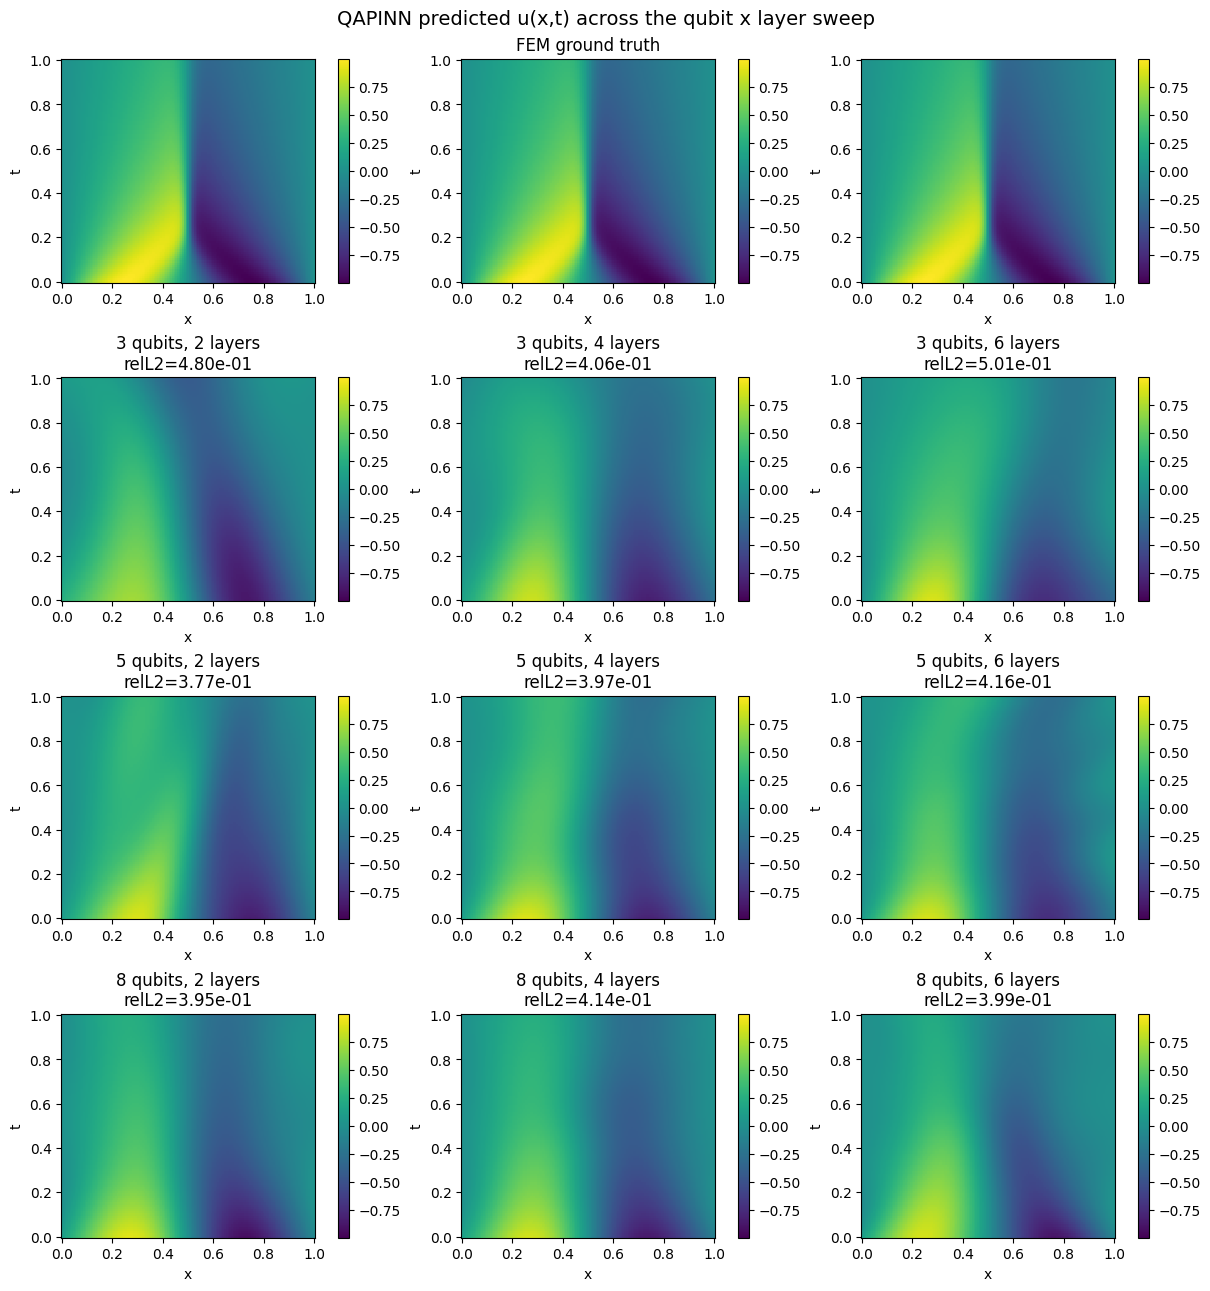

In [10]:
nrows, ncols = len(QUBIT_LIST), len(LAYER_LIST)
fig, axes = plt.subplots(nrows + 1, ncols, figsize=(4 * ncols, 3.2 * (nrows + 1)),
                         constrained_layout=True, squeeze=False)
vmin, vmax = U_eval.min(), U_eval.max()

# top row: FEM ground truth repeated for visual reference
for j in range(ncols):
    ax = axes[0][j]
    im = ax.pcolormesh(x_eval, t_eval, U_eval, shading="auto", cmap="viridis",
                       vmin=vmin, vmax=vmax)
    ax.set_title("FEM ground truth" if j == ncols // 2 else "")
    ax.set_xlabel("x"); ax.set_ylabel("t")
    fig.colorbar(im, ax=ax)

for i, nq in enumerate(QUBIT_LIST):
    for j, nl in enumerate(LAYER_LIST):
        ax = axes[i + 1][j]
        r = results[(nq, nl)]
        im = ax.pcolormesh(x_eval, t_eval, r["U_pred"], shading="auto",
                           cmap="viridis", vmin=vmin, vmax=vmax)
        ax.set_title(f"{nq} qubits, {nl} layers\nrelL2={r['rel_l2']:.2e}")
        ax.set_xlabel("x"); ax.set_ylabel("t")
        fig.colorbar(im, ax=ax)
fig.suptitle("QAPINN predicted u(x,t) across the qubit x layer sweep", fontsize=14)
plt.show()

## 10. Convergence curves

Total-loss convergence for every configuration on a shared log axis — grouped by
qubit count. Deeper/wider circuits generally lower the achievable loss but at a
steeper per-epoch cost.

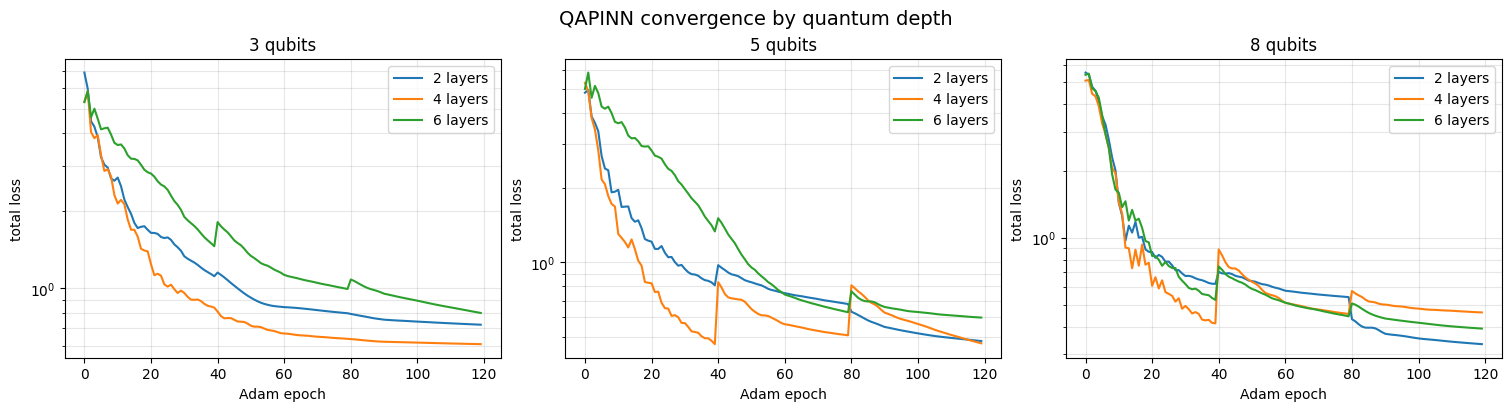

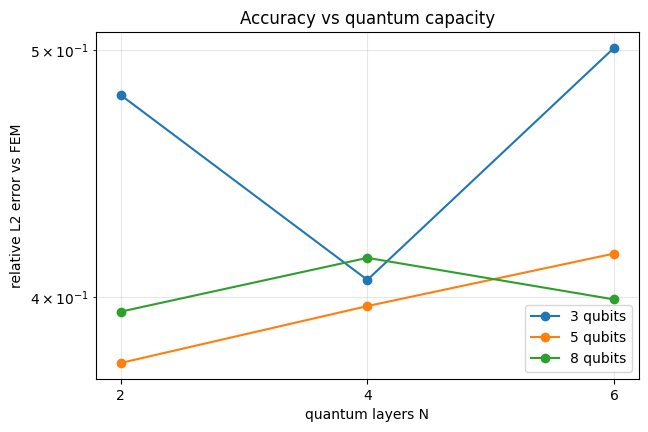

In [11]:
fig, axes = plt.subplots(1, len(QUBIT_LIST), figsize=(5 * len(QUBIT_LIST), 4),
                         constrained_layout=True, squeeze=False)
for i, nq in enumerate(QUBIT_LIST):
    ax = axes[0][i]
    for nl in LAYER_LIST:
        ax.semilogy(results[(nq, nl)]["hist"]["total"], label=f"{nl} layers")
    ax.set_title(f"{nq} qubits"); ax.set_xlabel("Adam epoch")
    ax.set_ylabel("total loss"); ax.legend(); ax.grid(alpha=0.3, which="both")
fig.suptitle("QAPINN convergence by quantum depth", fontsize=14)
plt.show()

# accuracy vs capacity summary
fig, ax = plt.subplots(figsize=(7, 4.5))
for nq in QUBIT_LIST:
    ax.plot(LAYER_LIST, [results[(nq, nl)]["rel_l2"] for nl in LAYER_LIST],
            "o-", label=f"{nq} qubits")
ax.set_xlabel("quantum layers N"); ax.set_ylabel("relative L2 error vs FEM")
ax.set_yscale("log"); ax.set_xticks(LAYER_LIST)
ax.set_title("Accuracy vs quantum capacity"); ax.legend(); ax.grid(alpha=0.3, which="both")
plt.show()

## 11. Best configuration — detailed comparison and solution profiles

For the most accurate configuration we compare the resolved field against FEM and
overlay solution profiles $u(\cdot,t)$ at several times to inspect how well the
quantum-assisted network captures the advecting/steepening front.

best config: 5 qubits, 2 layers | relL2=3.769e-01


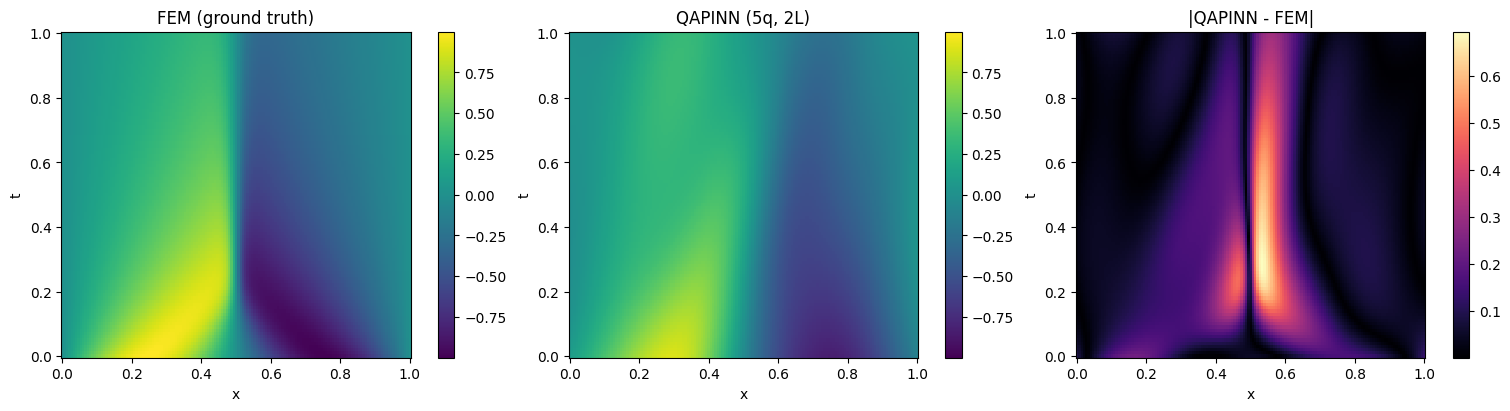

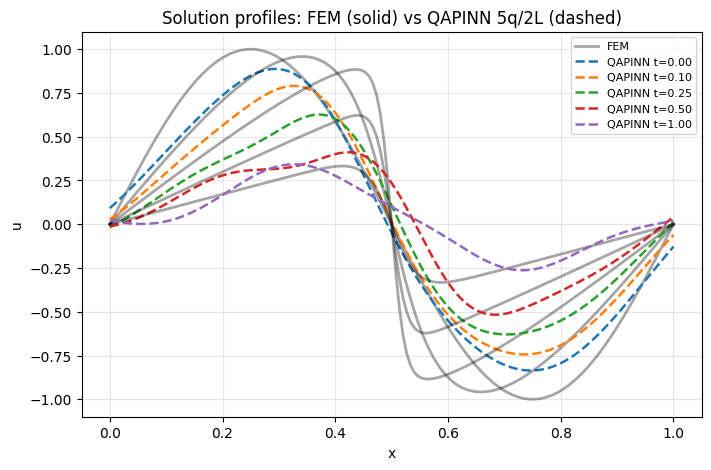

In [12]:
best_key = min(results, key=lambda k: results[k]["rel_l2"])
best_res = results[best_key]
U_pred_b = best_res["U_pred"]
print(f"best config: {best_key[0]} qubits, {best_key[1]} layers | "
      f"relL2={best_res['rel_l2']:.3e}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
vmin, vmax = U_eval.min(), U_eval.max()
for ax, field, title in [(axes[0], U_eval, "FEM (ground truth)"),
                         (axes[1], U_pred_b,
                          f"QAPINN ({best_key[0]}q, {best_key[1]}L)")]:
    im = ax.pcolormesh(x_eval, t_eval, field, shading="auto", cmap="viridis",
                       vmin=vmin, vmax=vmax)
    ax.set_xlabel("x"); ax.set_ylabel("t"); ax.set_title(title); fig.colorbar(im, ax=ax)
im = axes[2].pcolormesh(x_eval, t_eval, np.abs(U_pred_b - U_eval), shading="auto",
                        cmap="magma")
axes[2].set_xlabel("x"); axes[2].set_ylabel("t"); axes[2].set_title("|QAPINN - FEM|")
fig.colorbar(im, ax=axes[2])
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
for frac in [0.0, 0.1, 0.25, 0.5, 1.0]:
    k = int(frac * (len(t_eval) - 1))
    ax.plot(x_eval, U_eval[k], color="k", lw=2, alpha=0.35,
            label="FEM" if frac == 0.0 else None)
    ax.plot(x_eval, U_pred_b[k], "--", lw=1.8, label=f"QAPINN t={t_eval[k]:.2f}")
ax.set_xlabel("x"); ax.set_ylabel("u")
ax.set_title(f"Solution profiles: FEM (solid) vs QAPINN {best_key[0]}q/{best_key[1]}L (dashed)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.show()

## 12. Save results

Persist the sweep summary (all loss components, accuracy, timing) and the best
hybrid model's weights.

In [13]:
os.makedirs("checkpoints", exist_ok=True)
summary = {
    "physics": {"nu": NU, "domain": [XMIN, XMAX], "T": TMAX},
    "sweep": {"qubits": QUBIT_LIST, "layers": LAYER_LIST, "epochs": SWEEP_EPOCHS,
              "n_data": N_DATA_Q, "n_coll": N_COLL_Q, "n_bcic": N_BCIC_Q, "lr": LR},
    "results": [
        {"n_qubits": nq, "n_layers": nl,
         "n_params": results[(nq, nl)]["n_params"],
         "final_total": results[(nq, nl)]["hist"]["total"][-1],
         "L_data": results[(nq, nl)]["final"][0], "L_pde": results[(nq, nl)]["final"][1],
         "L_ic": results[(nq, nl)]["final"][2],   "L_bc": results[(nq, nl)]["final"][3],
         "rel_l2_vs_fem": results[(nq, nl)]["rel_l2"],
         "train_time_s": results[(nq, nl)]["train_time"]}
        for nq in QUBIT_LIST for nl in LAYER_LIST
    ],
    "best": {"n_qubits": best_key[0], "n_layers": best_key[1],
             "rel_l2_vs_fem": best_res["rel_l2"]},
}
with open(os.path.join("checkpoints", "qapinn_sweep_results.json"), "w") as fh:
    json.dump(summary, fh, indent=2)

torch.save({
    "state_dict": best_res["model"].state_dict(),
    "arch": f"QAPINN(n_qubits={best_key[0]}, n_layers={best_key[1]})",
    "nu": NU, "domain": [XMIN, XMAX], "T": TMAX,
    "rel_l2_vs_fem": best_res["rel_l2"],
}, os.path.join("checkpoints", "qapinn_best.pt"))
print("saved -> checkpoints/qapinn_sweep_results.json")
print(f"saved -> checkpoints/qapinn_best.pt  (best {best_key[0]}q/{best_key[1]}L, "
      f"relL2={best_res['rel_l2']:.3e})")

saved -> checkpoints/qapinn_sweep_results.json
saved -> checkpoints/qapinn_best.pt  (best 5q/2L, relL2=3.769e-01)


## Notes & interpretation

- **Hybrid autodiff works end-to-end.** Because the QNode uses
  `diff_method="backprop"` on `default.qubit`, PyTorch differentiates through the
  simulated circuit and forms the second-order residual $u_{xx}$, updating the
  quantum rotation angles jointly with the classical encoder/decoder weights.
- **Capacity vs cost.** More qubits ($2^n$ probability features) and more
  variational layers increase expressivity, but simulation cost grows quickly with
  qubit count — the 8-qubit runs dominate the sweep wall-clock. The accuracy-vs-
  capacity plot (§10) shows whether the extra capacity actually buys lower PDE
  error on this problem.
- **Comparison to the classical baseline.** The classical MLP PINN reaches
  rel $L^2 \approx 5\times10^{-3}$ with far more optimizer iterations. This
  notebook's short quantum-simulated sweep is meant to characterize the *hybrid*
  architecture's behavior, not to beat the classical model — increase
  `QAPINN_EPOCHS` (and the point counts) to push the accuracy of a chosen config.
- **Reproducibility knobs.** All sweep sizes are env-overridable
  (`QAPINN_QUBITS`, `QAPINN_LAYERS`, `QAPINN_EPOCHS`, `QAPINN_NDATA`,
  `QAPINN_NCOLL`, `QAPINN_NBCIC`, `QAPINN_LR`).